# Practice 1: PyTorch FashionMNIST Classification

## MLP vs DiagnosticCNN — Comparison

| Step | Description | What it does | Import path |
|------|-------------|--------------|-------------|
| 1 | Import Libraries | Load PyTorch, src modules, detect device | — |
| 2 | Load Dataset | Plain (MLP) + Augmented (CNN) datasets | `src/data_utils.py` |
| 3 | Explore Dataset | Shape, class distribution, pixel stats | `src/vis_utils.py` |
| 4 | Create DataLoaders | Plain loaders for MLP, augmented for CNN | `src/data_utils.py` |
| 5 | Define Models | MLP (215→470→10) vs DiagnosticCNN | — |
| 6 | Train Both Models | MLP: 10ep plain; CNN: 35ep augmented | `src/train_utils.py` |\n
| 7 | Compare: Loss Curves | Train + val loss curves | `src/vis_utils.py` |
| 8 | Compare: Confusion Matrices | Per-class TPR/FPR/Precision + heatmaps | `src/eval_utils.py` |
| 9 | Compare: ROC Curves | Per-class ROC curves + AUC scores | `src/eval_utils.py` + `src/vis_utils.py` |
| 10 | Compare: PR Curves | Per-class PR curves + AP | `src/eval_utils.py` + `src/vis_utils.py` |
| 11 | Summary Table | Accuracy / ROC-AUC / PR-AUC / Params | `src/eval_utils.py` |
| 12 | Save Models | Save .pth weights | `src/model_utils.py` |
| 13 | Display Predictions | Predicted vs actual images | `src/vis_utils.py` |

---

## 1. Import Libraries

In [1]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, random_split
import copy

from src.data_utils import get_fashionmnist_transforms, get_augmented_transforms, load_fashionmnist
from src.vis_utils import explore_dataset, plot_losses, plot_confusion_matrix
from src.vis_utils import plot_roc_curves, plot_pr_curves, plot_predictions
from src.model_utils import save_model
from src.train_utils import train_model
from src.eval_utils import evaluate_detailed, get_all_probas_and_labels
from src.eval_utils import compute_roc_auc_scores, compute_pr_auc_scores, print_comparison_table

print(f"PyTorch version: {torch.__version__}")
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

PyTorch version: 2.8.0
Using device: mps


## 2. Load Dataset

MLP: plain data. CNN: augmented (RandomRotation, RandomAffine, ColorJitter, RandomErasing).

Test: `ToTensor()` + `Normalize(0.5, 0.5)`.

In [2]:
test_transform = get_fashionmnist_transforms()
train_plain, test_dataset = load_fashionmnist(test_transform)
train_aug, _ = load_fashionmnist(test_transform, train_transform=get_augmented_transforms())

## 3. Explore Dataset

Print basic info (classes, shape), show 10 clean sample images, class distribution bar chart, and pixel intensity histogram.

Number of classes: 10
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Num samples: 60000
Image shape: torch.Size([1, 28, 28])


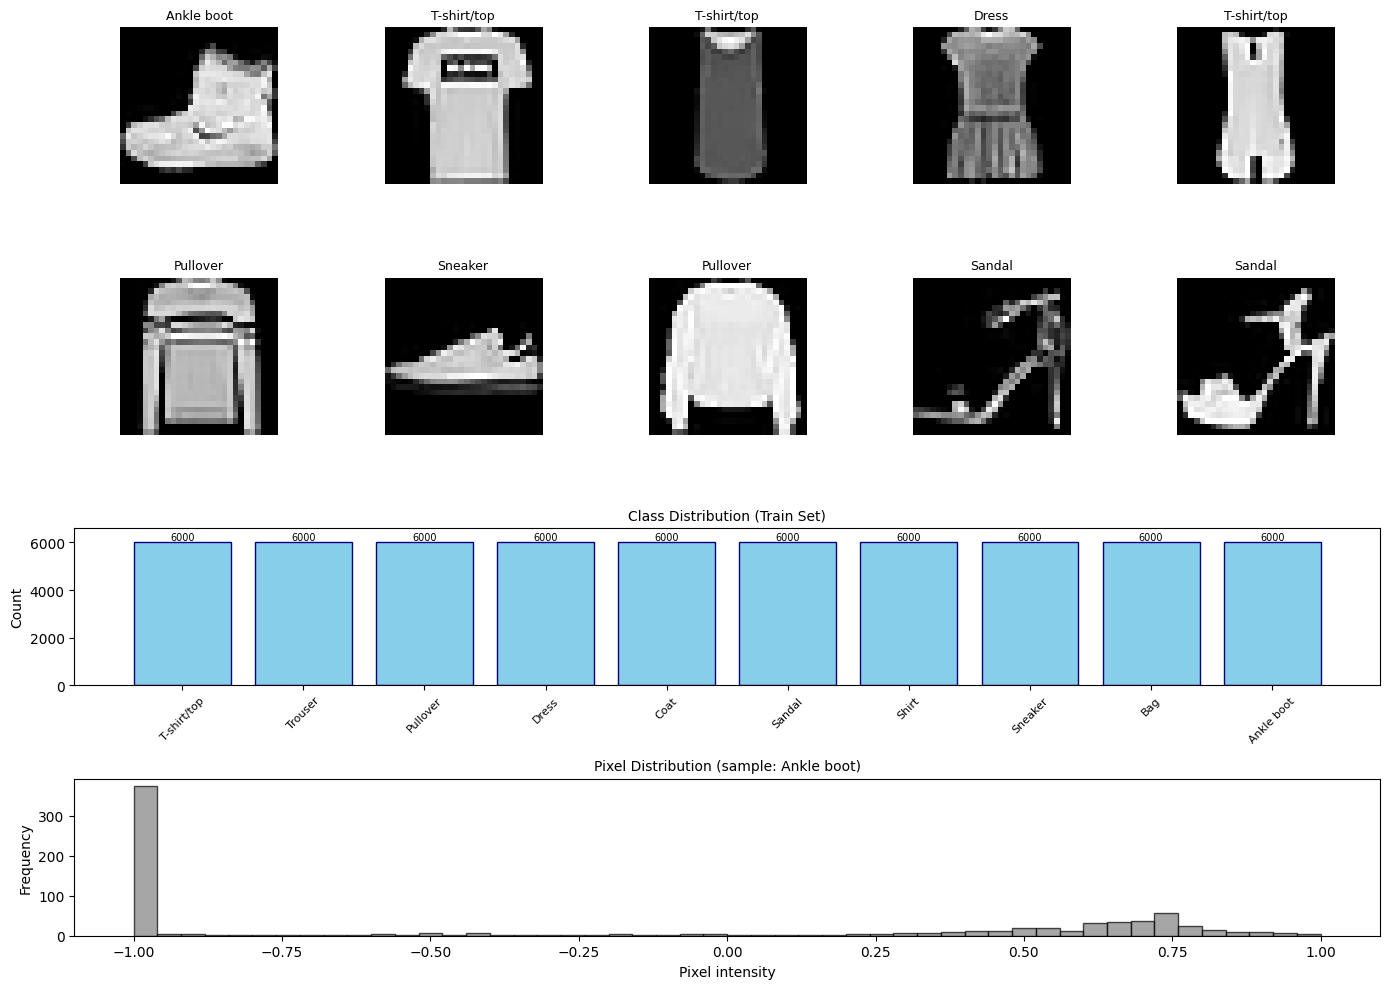

Image tensor shape: torch.Size([1, 28, 28])
Image tensor dtype: torch.float32
Pixel value range: [-1.0000, 1.0000]
Mean pixel value: -0.2372
Std pixel value: 0.7989


In [3]:
class_names = train_plain.classes
explore_dataset(train_plain, class_names)

## 4. Create DataLoaders

Train/val split (6K). Plain loaders for MLP, augmented loaders for CNN.

In [4]:
val_size = 6000

train_sub, val_sub = random_split(
    train_plain, [len(train_plain) - val_size, val_size],
    generator=torch.Generator().manual_seed(42))
train_loader = DataLoader(train_sub, batch_size=64, shuffle=True)
val_loader = DataLoader(val_sub, batch_size=256, shuffle=False)

train_sub_aug, val_sub_aug = random_split(
    train_aug, [len(train_aug) - val_size, val_size],
    generator=torch.Generator().manual_seed(42))
train_loader_cnn = DataLoader(train_sub_aug, batch_size=64, shuffle=True)
val_loader_cnn = DataLoader(val_sub_aug, batch_size=256, shuffle=False)

test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
print(f"Train: {len(train_sub)}  Val: {len(val_sub)}  Test: {len(test_dataset)}")

Train: 54000  Val: 6000  Test: 10000


## 5. Define Models

**MLP:** `784 -> 215 -> 470 -> 10`, GELU, Dropout(0.05). HP from Optuna.

**DiagnosticCNN:** 3 conv blocks (32→64→128), BatchNorm, ReLU, GAP, Dropout(0.454). HP from Optuna.

In [5]:
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_1=215, hidden_2=470, num_classes=10, dropout=0.15 ):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_size, hidden_1)
        self.fc2 = nn.Linear(hidden_1, hidden_2)
        self.fc3 = nn.Linear(hidden_2, num_classes)
        self.act = nn.GELU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.flatten(x)
        x = self.act(self.fc1(x))
        x = self.dropout(x)
        x = self.act(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x


class DiagnosticCNN(nn.Module):
    def __init__(self, dropout=0.454):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(dropout), nn.Linear(128, 10),
        )
    def forward(self, x):
        return self.net(x)


model_mlp = MLP().to(device)
model_cnn = DiagnosticCNN().to(device)

mlp_params = sum(p.numel() for p in model_mlp.parameters())
cnn_params = sum(p.numel() for p in model_cnn.parameters())
print(f'MLP params: {mlp_params:,}')
print(f'CNN params: {cnn_params:,}')

MLP params: 275,005
CNN params: 140,778


## 6. Train Both Models

MLP: plain data, `AdamW(lr=0.002, wd=2e-6)`, 10 epochs, `CosineAnnealingLR`, early stop patience=5.

CNN: augmented data, `AdamW(lr=0.003322, wd=1.39e-5)`, 35 epochs, early stop patience=5.

In [6]:
criterion = nn.CrossEntropyLoss()

print('--- Training MLP (plain data) ---')
optimizer_mlp = optim.AdamW(model_mlp.parameters(), lr=0.002, weight_decay=2e-6)
scheduler_mlp = CosineAnnealingLR(optimizer_mlp, T_max=10)
train_losses_mlp = []
val_losses_mlp = []
best_val_loss = float('inf')
best_mlp_state = None
patience = 5
wait = 0
model_mlp.train()
for epoch in range(10):
    from src.train_utils import train_one_epoch
    train_loss = train_one_epoch(model_mlp, train_loader, criterion, optimizer_mlp, device)
    train_losses_mlp.append(train_loss)
    scheduler_mlp.step()

    model_mlp.eval()
    vloss = 0.0
    with torch.no_grad():
        for img, lbl in val_loader:
            img, lbl = img.to(device), lbl.to(device)
            vloss += criterion(model_mlp(img), lbl).item()
    val_losses_mlp.append(vloss / len(val_loader))
    model_mlp.train()

    if val_losses_mlp[-1] < best_val_loss:
        best_val_loss = val_losses_mlp[-1]
        best_mlp_state = copy.deepcopy(model_mlp.state_dict())
        wait = 0
    else:
        wait += 1

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/10]  Train: {train_loss:.4f}  Val: {val_losses_mlp[-1]:.4f}')

    if wait >= patience:
        print(f'Early stop at epoch {epoch+1}')
        break

model_mlp.load_state_dict(best_mlp_state)
print(f'Restored best MLP checkpoint (val_loss={best_val_loss:.4f})')

import os
os.makedirs('../outputs/practice_1/metrics', exist_ok=True)
for name, losses in [('train_losses_MLP.txt', train_losses_mlp), ('val_losses_MLP.txt', val_losses_mlp)]:
    with open(f'../outputs/practice_1/metrics/{name}', 'w') as f:
        for l in losses:
            f.write(f'{l}\n')

print('\n--- Training DiagnosticCNN (augmented data) ---')
EPOCHS_CNN = 35
optimizer_cnn = optim.AdamW(model_cnn.parameters(), lr=0.003322, weight_decay=1.39e-5)
scheduler_cnn = CosineAnnealingLR(optimizer_cnn, T_max=EPOCHS_CNN)
train_losses_cnn = []
val_losses_cnn = []
best_val_loss_cnn = float('inf')
best_cnn_state = None
wait_cnn = 0
model_cnn.train()
for epoch in range(EPOCHS_CNN):
    from src.train_utils import train_one_epoch
    train_loss = train_one_epoch(model_cnn, train_loader_cnn, criterion, optimizer_cnn, device)
    train_losses_cnn.append(train_loss)
    scheduler_cnn.step()

    model_cnn.eval()
    vloss = 0.0
    with torch.no_grad():
        for img, lbl in val_loader_cnn:
            img, lbl = img.to(device), lbl.to(device)
            vloss += criterion(model_cnn(img), lbl).item()
    val_losses_cnn.append(vloss / len(val_loader_cnn))
    model_cnn.train()

    if val_losses_cnn[-1] < best_val_loss_cnn:
        best_val_loss_cnn = val_losses_cnn[-1]
        best_cnn_state = copy.deepcopy(model_cnn.state_dict())
        wait_cnn = 0
    else:
        wait_cnn += 1

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/{EPOCHS_CNN}]  Train: {train_loss:.4f}  Val: {val_losses_cnn[-1]:.4f}')

    if wait_cnn >= patience:
        print(f'Early stop at epoch {epoch+1}')
        break

model_cnn.load_state_dict(best_cnn_state)
print(f'Restored best CNN checkpoint (val_loss={best_val_loss_cnn:.4f})')
for name, losses in [('train_losses_CNN.txt', train_losses_cnn), ('val_losses_CNN.txt', val_losses_cnn)]:
    with open(f'../outputs/practice_1/metrics/{name}', 'w') as f:
        for l in losses:
            f.write(f'{l}\n')

--- Training MLP (plain data) ---
Epoch [1/10]  Train: 0.5245  Val: 0.4364
Epoch [5/10]  Train: 0.3217  Val: 0.3366
Epoch [10/10]  Train: 0.2144  Val: 0.2872
Restored best MLP checkpoint (val_loss=0.2872)

--- Training DiagnosticCNN (augmented data) ---
Epoch [1/35]  Train: 0.7208  Val: 0.5446
Epoch [5/35]  Train: 0.3940  Val: 0.3679
Epoch [10/35]  Train: 0.3314  Val: 0.3106
Epoch [15/35]  Train: 0.2961  Val: 0.2882
Epoch [20/35]  Train: 0.2685  Val: 0.2652
Epoch [25/35]  Train: 0.2444  Val: 0.2523
Epoch [30/35]  Train: 0.2362  Val: 0.2379
Epoch [35/35]  Train: 0.2316  Val: 0.2397
Restored best CNN checkpoint (val_loss=0.2315)


## 7. Compare: Loss Curves\n
\n
Separate plots for MLP and CNN. Solid = training loss, dashed = validation loss.

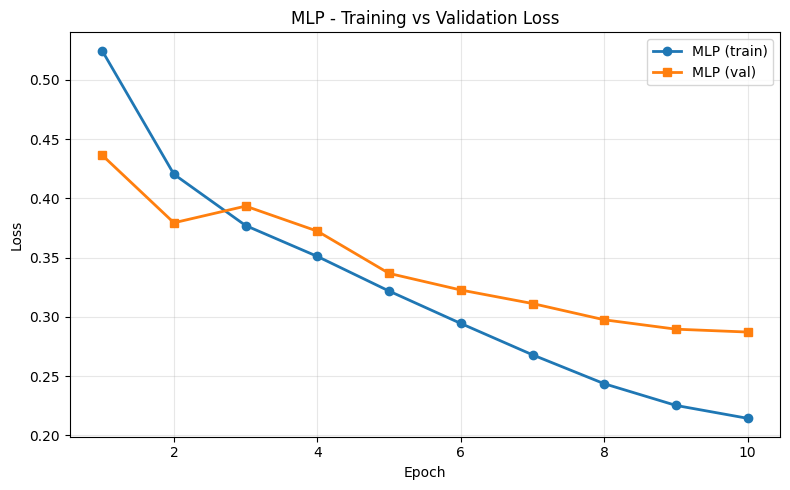

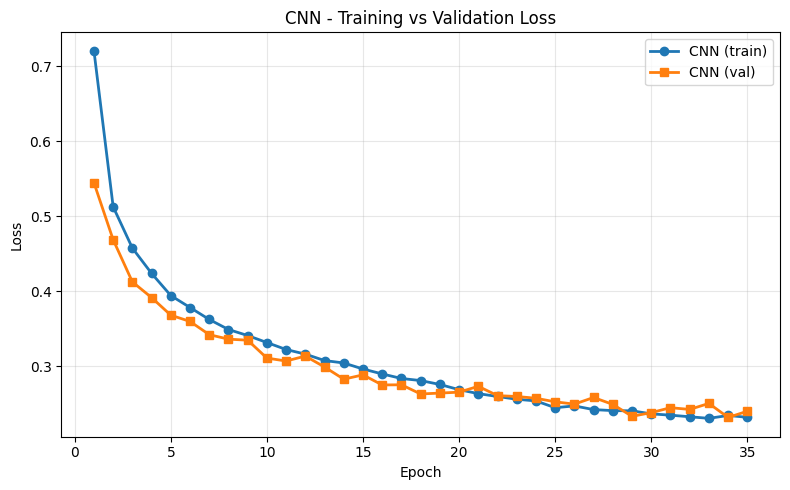

In [7]:
plot_losses({'MLP (train)': train_losses_mlp, 'MLP (val)': val_losses_mlp},
           title='MLP - Training vs Validation Loss',
           save_path='../outputs/practice_1/plots/mlp_loss.png')
plot_losses({'CNN (train)': train_losses_cnn, 'CNN (val)': val_losses_cnn},
           title='CNN - Training vs Validation Loss',
           save_path='../outputs/practice_1/plots/cnn_loss.png')

## 8. Compare: Confusion Matrices

  Test Accuracy: 89.23%
  Class           TPR(Recall)        FPR  Precision
  ---------------------------------------------
  T-shirt/top         0.8710     0.0204     0.8256
  Trouser             0.9710     0.0010     0.9908
  Pullover            0.8270     0.0220     0.8068
  Dress               0.9050     0.0130     0.8855
  Coat                0.8370     0.0204     0.8198
  Sandal              0.9580     0.0036     0.9677
  Shirt               0.6770     0.0236     0.7615
  Sneaker             0.9520     0.0076     0.9333
  Bag                 0.9720     0.0031     0.9720
  Ankle boot          0.9530     0.0050     0.9549


  Test Accuracy: 92.94%
  Class           TPR(Recall)        FPR  Precision
  ---------------------------------------------
  T-shirt/top         0.8890     0.0159     0.8614
  Trouser             0.9900     0.0007     0.9940
  Pullover            0.9120     0.0126     0.8898
  Dress               0.9260     0.0068     0.9382
  Coat                0.9100     0.0

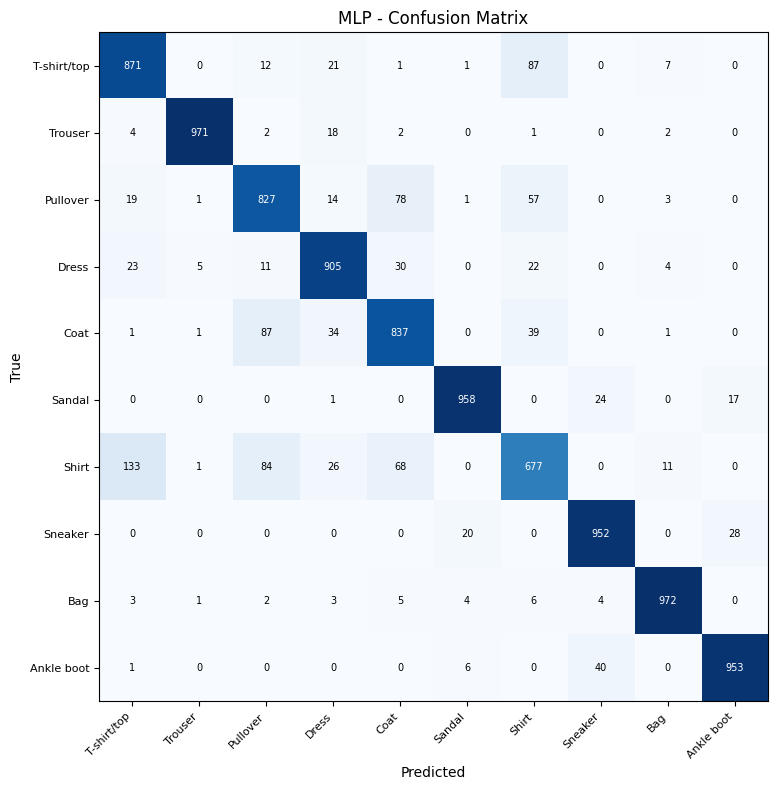

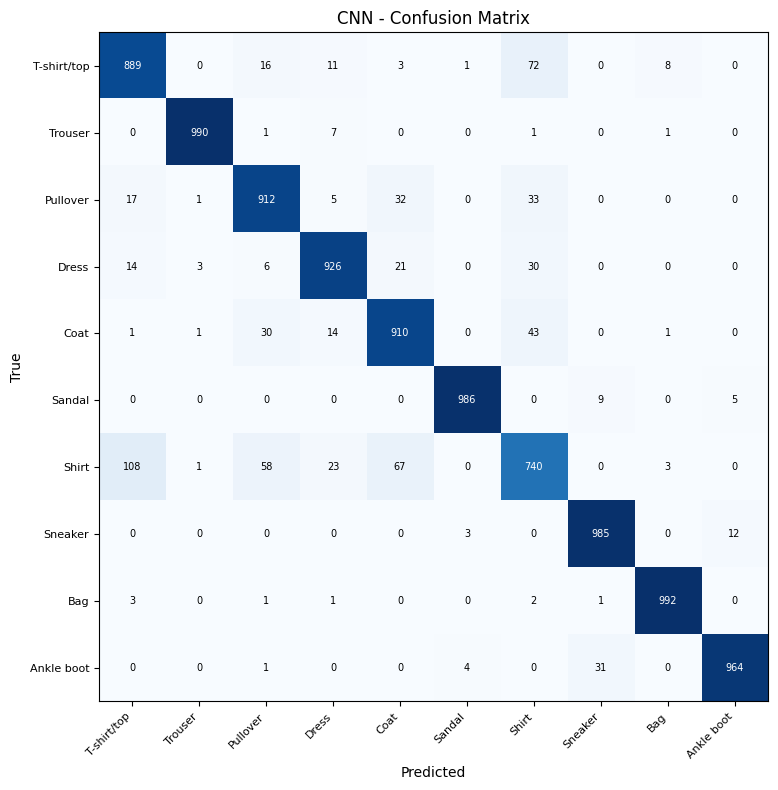

In [8]:
acc_mlp, cm_mlp, _ = evaluate_detailed(model_mlp, test_loader, device, class_names)
print('\n')
acc_cnn, cm_cnn, _ = evaluate_detailed(model_cnn, test_loader, device, class_names)

plot_confusion_matrix(cm_mlp, class_names, title='MLP - Confusion Matrix',
                      save_path='../outputs/practice_1/plots/confusion_matrix_mlp.png')
plot_confusion_matrix(cm_cnn, class_names, title='CNN - Confusion Matrix',
                      save_path='../outputs/practice_1/plots/confusion_matrix_cnn.png')

## 9. Compare: ROC Curves

MLP macro ROC-AUC: 0.9918
CNN macro ROC-AUC: 0.9962


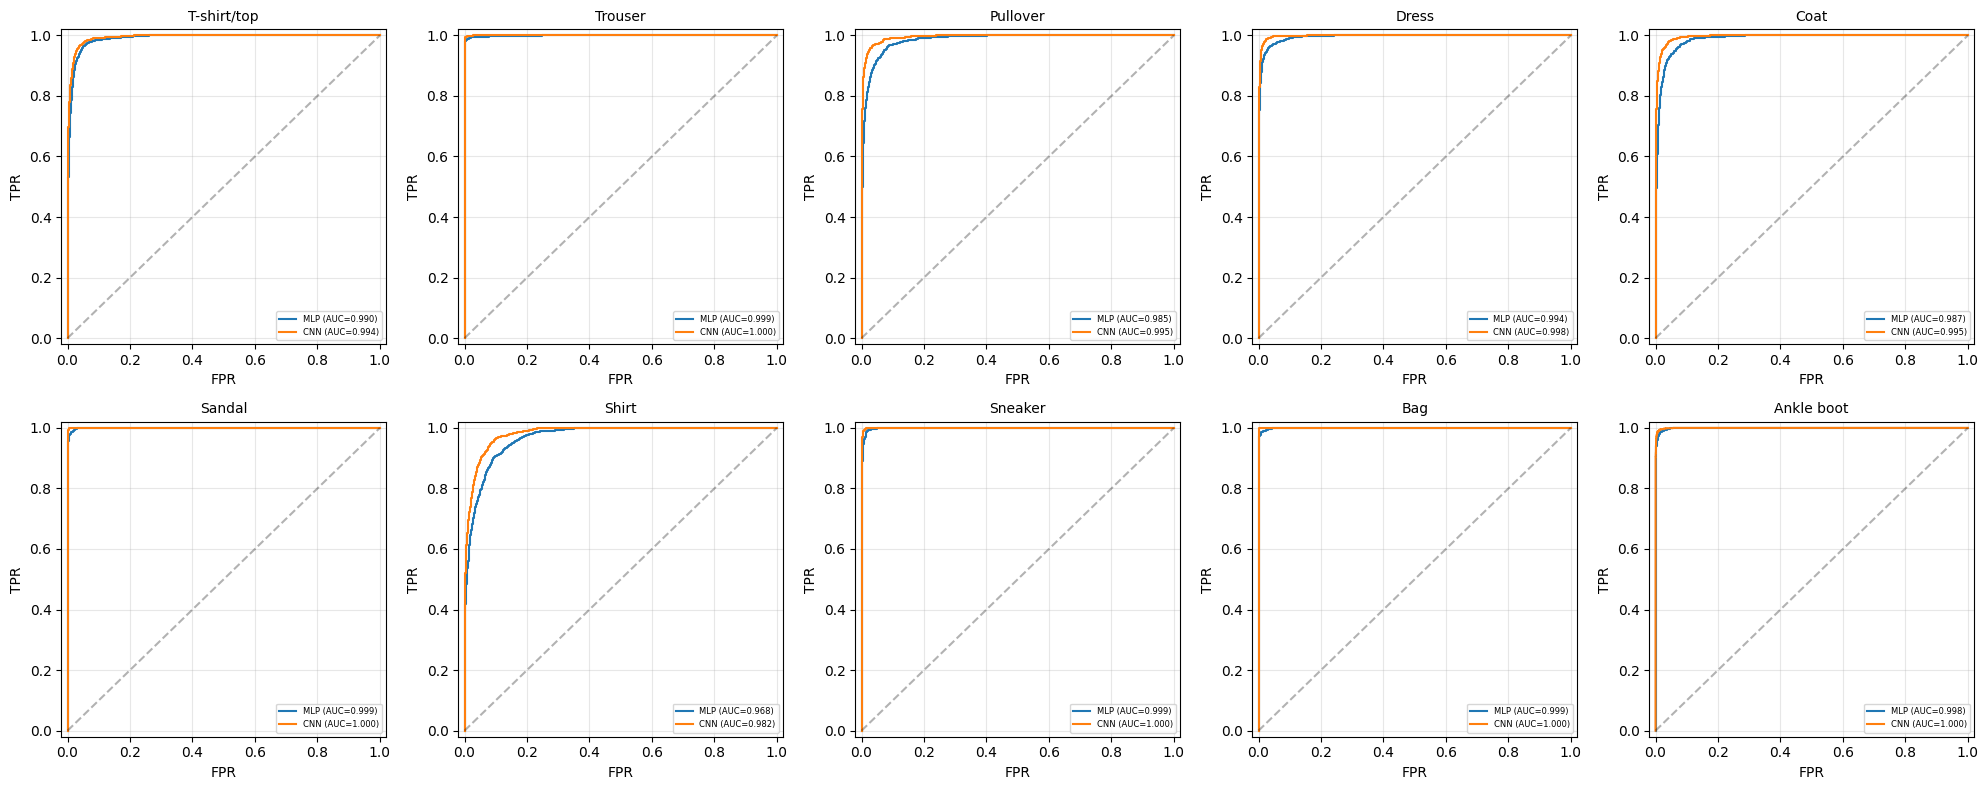

In [9]:
probas_mlp, labels = get_all_probas_and_labels(model_mlp, test_loader, device, 10)
probas_cnn, _ = get_all_probas_and_labels(model_cnn, test_loader, device, 10)

roc_mlp = compute_roc_auc_scores(probas_mlp, labels)
roc_cnn = compute_roc_auc_scores(probas_cnn, labels)
print(f'MLP macro ROC-AUC: {roc_mlp["macro"]:.4f}')
print(f'CNN macro ROC-AUC: {roc_cnn["macro"]:.4f}')
plot_roc_curves({'MLP': probas_mlp, 'CNN': probas_cnn}, labels, class_names)

## 10. Compare: PR Curves

MLP macro PR-AUC (AP): 0.9446
CNN macro PR-AUC (AP): 0.9734


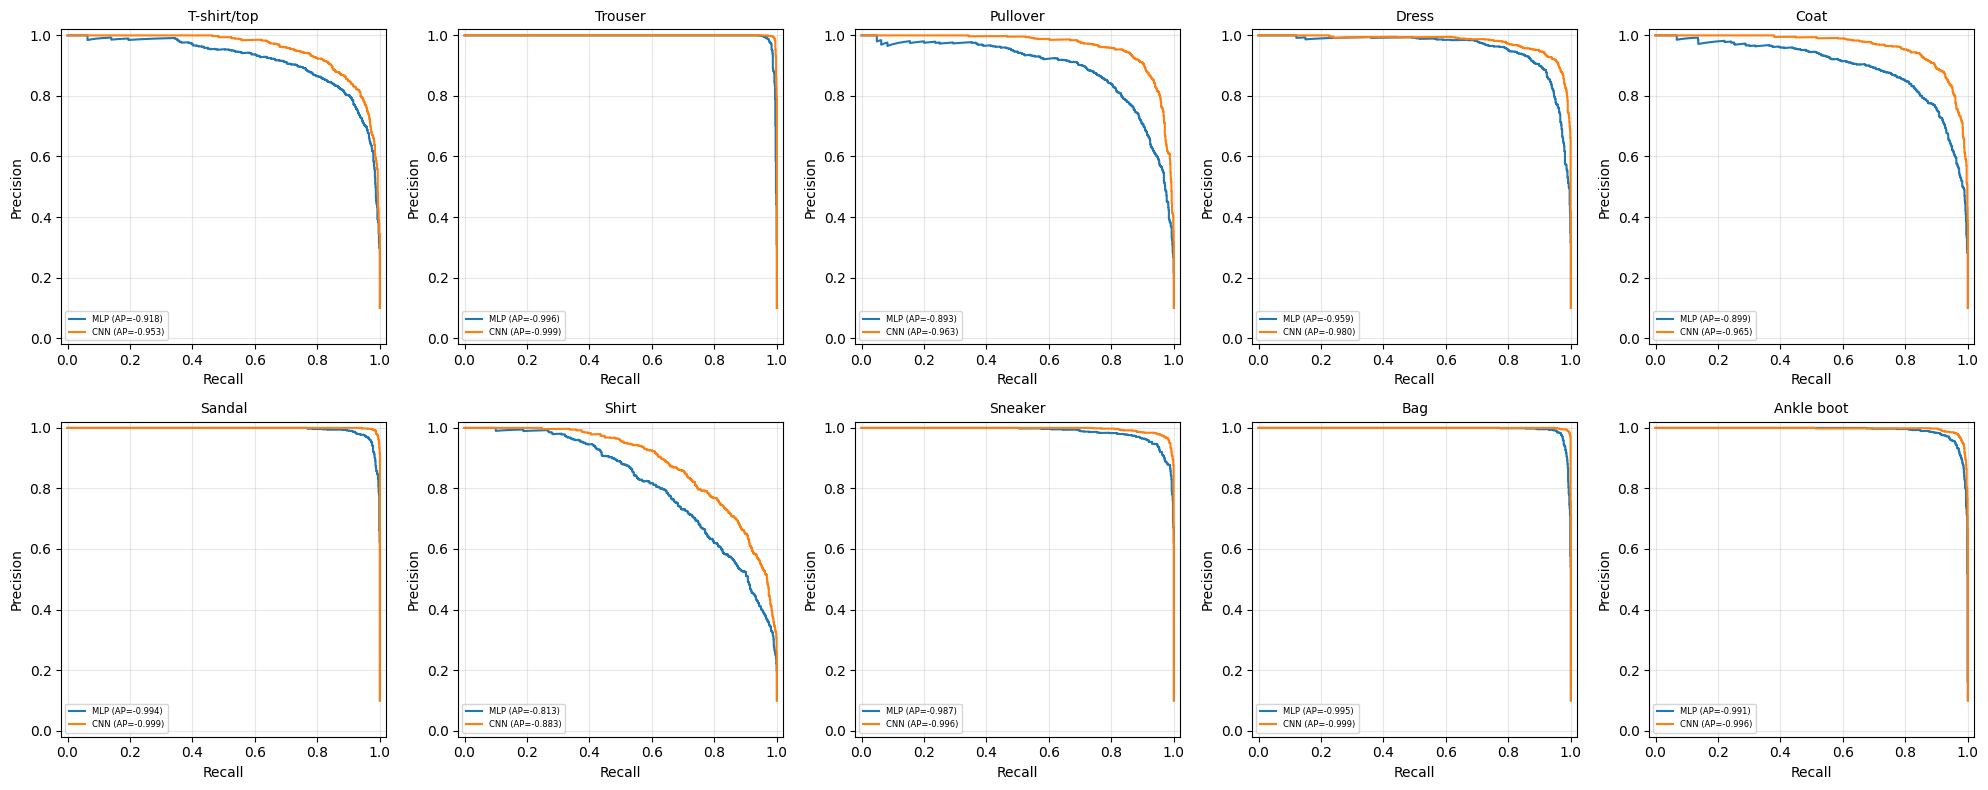

In [10]:
pr_mlp = compute_pr_auc_scores(probas_mlp, labels)
pr_cnn = compute_pr_auc_scores(probas_cnn, labels)
print(f'MLP macro PR-AUC (AP): {pr_mlp["macro"]:.4f}')
print(f'CNN macro PR-AUC (AP): {pr_cnn["macro"]:.4f}')
plot_pr_curves({'MLP': probas_mlp, 'CNN': probas_cnn}, labels, class_names)

## 11. Summary Table

In [11]:
print_comparison_table(acc_mlp, acc_cnn, roc_mlp, roc_cnn, pr_mlp, pr_cnn,
                       mlp_params, cnn_params, class_names)

Metric                             MLP          CNN         Diff
---------------------------------------------------------------------------
Test Accuracy (%)               89.23       92.94       +3.71
Macro ROC-AUC                  0.9918      0.9962     +0.0044
Macro PR-AUC (AP)              0.9446      0.9734     +0.0288
Parameters                    275,005     140,778    -134,227

Per-class ROC-AUC                  MLP          CNN
--------------------------------------------------
T-shirt/top                    0.9895      0.9936
Trouser                        0.9992      0.9999
Pullover                       0.9847      0.9946
Dress                          0.9944      0.9977
Coat                           0.9870      0.9954
Sandal                         0.9993      0.9999
Shirt                          0.9677      0.9819
Sneaker                        0.9985      0.9995
Bag                            0.9993      0.9999
Ankle boot                     0.9984      0.9995

Per-cl

## 12. Save Models

In [12]:
save_model(model_mlp, '../outputs/practice_1/model/mlp.pth')
save_model(model_cnn, '../outputs/practice_1/model/cnn.pth')

Model saved to ../outputs/practice_1/model/mlp.pth
Model saved to ../outputs/practice_1/model/cnn.pth


## 13. Display Predicted vs Actual Images

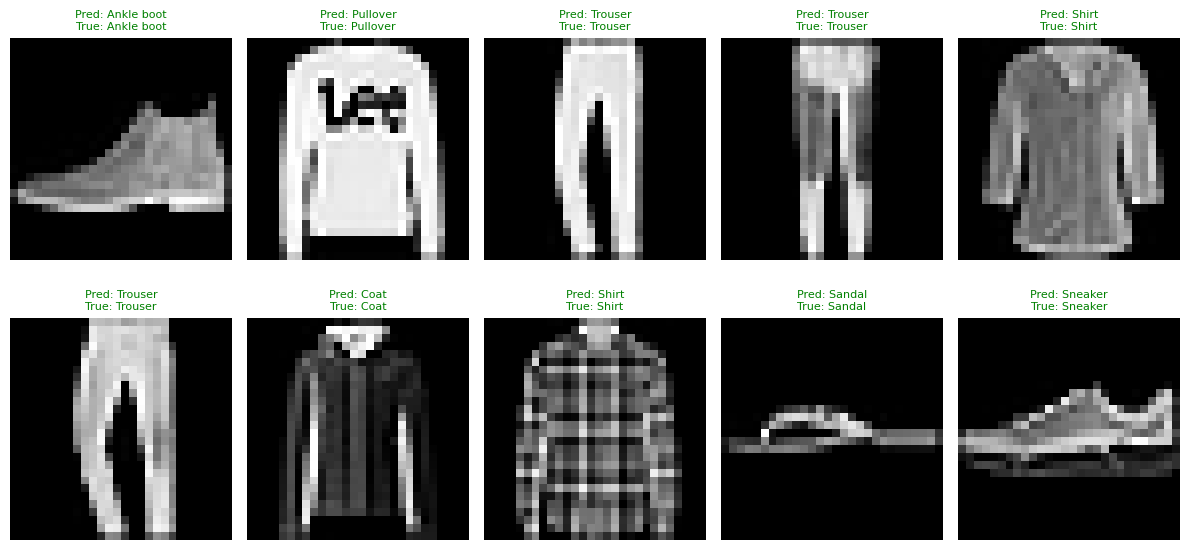

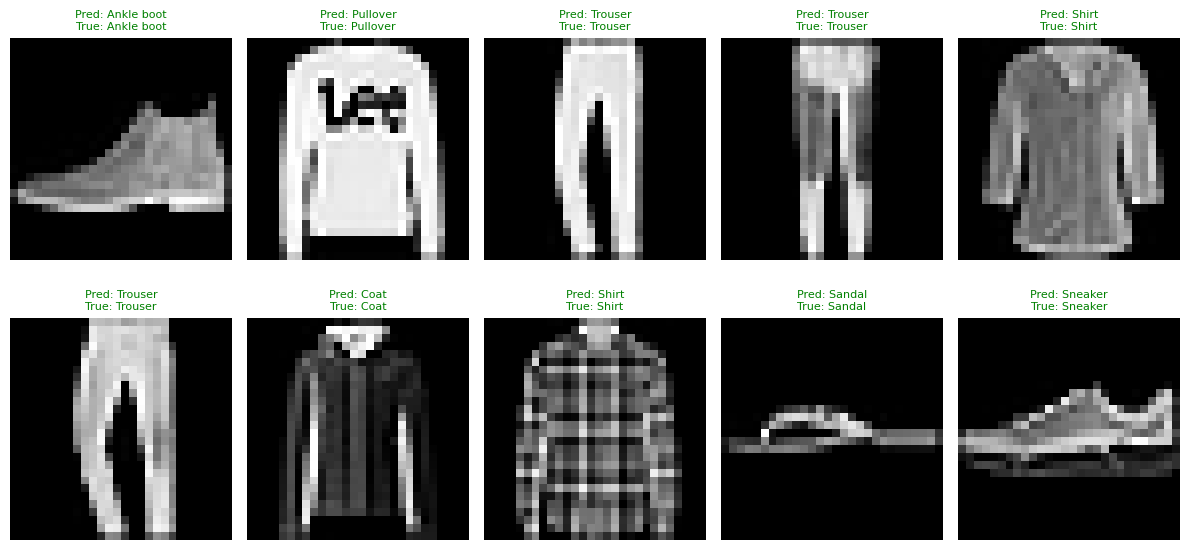

In [13]:
plot_predictions(model_mlp, test_loader, class_names, device,
               '../outputs/practice_1/plots/predictions_mlp.png')
plot_predictions(model_cnn, test_loader, class_names, device,
               '../outputs/practice_1/plots/predictions_cnn.png')